# Recognition of Objects using Neural Networks


## By: Ayush Trivedi

In [27]:
import tensorflow as tf
from keras.utils import np_utils
from matplotlib import pyplot as plt
import numpy as np

In [28]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()


In [29]:
print("Training Images: {}".format(X_train.shape))
print("Testing Images: {}".format(X_test.shape))


Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [30]:
print(X_train[0].shape)

(32, 32, 3)


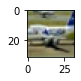

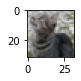

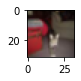

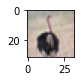

In [31]:
for i in range(332,336):
    plt.subplot(120+ 1 + i)
    #plt.figure(figsize=(4,3))
    img = X_train[i]
    plt.imshow(img)
   
    plt.show()

In [32]:
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

X_train /= 255
X_test=X_test/255
n_classes = 10

print("Shape before one-hot encoding: ", y_train.shape)
Y_train = np_utils.to_categorical(y_train, n_classes)
Y_test = np_utils.to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (50000, 1)
Shape after one-hot encoding:  (50000, 10)


In [33]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Flatten

model=Sequential()
#convolution layers
model.add(Conv2D(50, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu', input_shape=(32, 32, 3)))

model.add(Conv2D(75, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(125, kernel_size=(3,3), strides=(1,1), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

#hidden layers
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(250, activation='relu'))
model.add(Dropout(0.3))
#output layer
model.add(Dense(10, activation='softmax'))

#compiling
model.compile(loss='categorical_crossentropy', metrics=['accuracy'], optimizer='adam')

#training the model
model.fit(X_train, Y_train, epochs=20)

Epoch 1/20
1563/1563 [==============================] - 277s 176ms/step - loss: 1.4895 - accuracy: 0.4578
Epoch 2/20
1563/1563 [==============================] - 256s 164ms/step - loss: 1.0673 - accuracy: 0.6272
Epoch 3/20
1563/1563 [==============================] - 254s 162ms/step - loss: 0.9217 - accuracy: 0.6787
Epoch 4/20
1563/1563 [==============================] - 255s 163ms/step - loss: 0.8274 - accuracy: 0.7102
Epoch 5/20
1563/1563 [==============================] - 254s 163ms/step - loss: 0.7583 - accuracy: 0.7380
Epoch 6/20
1563/1563 [==============================] - 255s 163ms/step - loss: 0.7050 - accuracy: 0.7552
Epoch 7/20
1563/1563 [==============================] - 255s 163ms/step - loss: 0.6635 - accuracy: 0.7684
Epoch 8/20
1563/1563 [==============================] - 255s 163ms/step - loss: 0.6300 - accuracy: 0.7808
Epoch 9/20
1563/1563 [==============================] - 259s 165ms/step - loss: 0.5873 - accuracy: 0.7957
Epoch 10/20
1563/1563 [=======================

In [34]:
model.evaluate(X_test, Y_test)

313/313 [==============================] - 13s 40ms/step - loss: 0.6869 - accuracy: 0.7742


[0.6868529319763184, 0.7742000222206116]

In [35]:
classes = range(0,10)

names=['airplane',
      'automobile',
      'bird',
      'cat',
      'deer',
      'dog',
      'frog',
      'horse',
      'ship',
      'truck']

# zip the names and classes to make a dictionary of class_labels
class_labels = dict(zip(classes, names))

#generate batch of 9 images to predict
batch = X_test[100:109]
labels = np.argmax(Y_test[100:109], axis=-1)

# make predictions
predictions = model.predict(batch, verbose = 1)

1/1 [==============================] - 0s 69ms/step


In [36]:
print (predictions)

[[2.34275562e-04 1.00685827e-06 1.64782450e-01 2.60807481e-03
  7.52268314e-01 1.42294830e-02 1.00737023e-04 6.56152591e-02
  1.42471588e-04 1.79288054e-05]
 [3.92820360e-03 3.85362335e-04 5.73214330e-02 3.11381400e-01
  4.68868650e-02 3.97791535e-01 1.58980399e-01 2.08995529e-02
  1.18397246e-03 1.24125881e-03]
 [4.14591250e-06 1.84092380e-06 2.11438906e-04 2.72767735e-04
  3.96654650e-05 9.92450732e-05 9.99360383e-01 7.63201842e-06
  2.39382689e-06 5.19384230e-07]
 [5.72047080e-04 7.81633571e-05 1.46302963e-02 6.56154633e-01
  9.40251052e-02 1.90752402e-01 3.87856103e-02 4.61213989e-03
  1.67791586e-04 2.21828843e-04]
 [9.74964792e-13 9.99995232e-01 3.02069340e-16 3.00355665e-19
  6.46529578e-18 3.65347033e-20 3.19662138e-20 3.94968403e-18
  5.82419443e-12 4.80405697e-06]
 [2.47634404e-07 9.99986529e-01 1.65700925e-11 6.85764015e-15
  5.97517438e-14 1.59671259e-15 1.19237671e-12 3.61403642e-13
  1.34935033e-06 1.18579592e-05]
 [9.87697579e-03 2.87829479e-03 3.20117641e-03 2.96352059e

In [37]:
for image in predictions:
    print(np.sum(image))

0.99999994
0.99999994
1.0
1.0
1.0
1.0
0.9999999
1.0
1.0


In [38]:
class_result = np.argmax(predictions, axis=-1)
print (class_result)

[4 5 6 3 1 1 6 6 8]


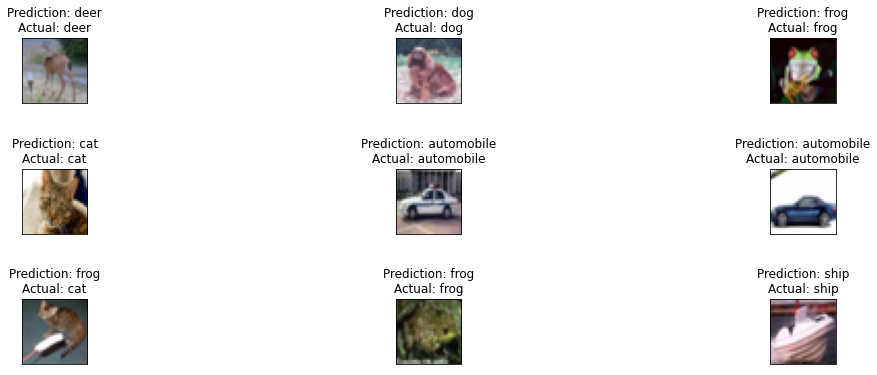

In [40]:
fig, axs = plt.subplots(3, 3, figsize = (19,6))
fig.subplots_adjust(hspace = 1)
axs = axs.flatten()

for i, img in enumerate(batch):
    for key, value in class_labels.items():
        if class_result[i] == key:
            title = 'Prediction: {}\nActual: {}'.format(class_labels[key], class_labels[labels[i]])
            axs[i].set_title(title)
            axs[i].axes.get_xaxis().set_visible(False)
            axs[i].axes.get_yaxis().set_visible(False)
            
    #plot the image
    axs[i].imshow(img)
    
#show the plot
plt.show()